# Exploratory Data Analysis (EDA)

In this notebook, exploratory data analysis is performed on the cleaned global market dataset to uncover trends, patterns, and relationships within the data.

The objective of this analysis is to gain a deeper understanding of market behavior across different asset classes, regions, and time periods before drawing conclusions or developing predictive models.

#### The objectives of this notebook are:

- Examine the overall structure of the cleaned dataset
- Generate descriptive statistics for key numerical variables
- Analyze the distribution of market prices and trading volume
- Explore the composition of assets by type and region
- Identify trends and patterns over time
- Investigate relationships between numerical features
- Visualize market behavior during major economic events
- Extract preliminary insights to support further analysis


In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

df = pd.read_csv("../Data/processed/cleaned_market_data.csv")
df.head()

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
0,2000-01-03,1469.2500,1478.0000,1438.3600,1455.2200,931800000,^GSPC,S&P500,Stock Index,Global
1,2000-01-03,4186.1899,4192.1899,3989.7100,4131.1499,1510070000,^IXIC,NASDAQ,Stock Index,Global
2,2000-01-03,17057.6992,17426.1602,17057.6992,17369.6309,0,^HSI,HSI,Stock Index,Global
3,2000-01-03,0.0098,0.0099,0.0097,0.0098,0,JPYUSD=X,JPY/USD,Currency,Global
4,2000-01-03,5209.5400,5384.6602,5209.5400,5375.1099,0,^BSESN,SENSEX,Stock Index,Global


## Dataset Overview

Before performing exploratory analysis, it is important to review the structure of the cleaned dataset. This includes examining the number of records, available features, and data types.

In [3]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 187611
Number of Columns: 10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187611 entries, 0 to 187610
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        187611 non-null  str    
 1   open        187611 non-null  float64
 2   high        187611 non-null  float64
 3   low         187611 non-null  float64
 4   close       187611 non-null  float64
 5   volume      187611 non-null  int64  
 6   symbol      187611 non-null  str    
 7   asset_name  187611 non-null  str    
 8   asset_type  187611 non-null  str    
 9   region      187611 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 14.3 MB


### Observation

The cleaned dataset contains financial market data for multiple assets across different regions. The dataset consists of numerical, categorical, and temporal features required for further exploratory analysis.

## Summary Statistics

Descriptive statistics provide an overview of the central tendency, spread, and distribution of numerical variables within the dataset.

In [5]:
df.describe()

,open,high,low,close,volume
count,187611.000000,187611.000000,187611.000000,187611.000000,1.876110e+05
mean,4408.078092,4444.787018,4366.875968,4407.227970,1.247674e+09
std,10646.457796,10750.171471,10531.420024,10644.700449,5.489795e+09
min,-14.000000,0.001200,-40.320000,-37.630000,0.000000e+00
25%,1.152600,1.160200,1.143150,1.152500,0.000000e+00
50%,125.060000,128.666100,122.100000,125.126700,7.182200e+04
75%,3343.026000,3375.043450,3310.429950,3342.126450,2.232844e+08
max,124752.140600,126198.070300,123196.046900,124752.531200,3.509679e+11


### Observation

The summary statistics provide insights into the range and variability of market prices and trading volumes. Significant differences between minimum and maximum values suggest varying scales across different financial assets.

## Asset Composition Analysis

This section examines the composition of the dataset across asset categories and geographic regions.

In [6]:
# unique assets
print("Unique Assets:", df["asset_name"].nunique())

Unique Assets: 34


In [7]:
# unique assets type
df["asset_type"].value_counts()

asset_type
Stock Index       63610
Commodity         49965
Currency          47629
Cryptocurrency    26407
Name: count, dtype: int64

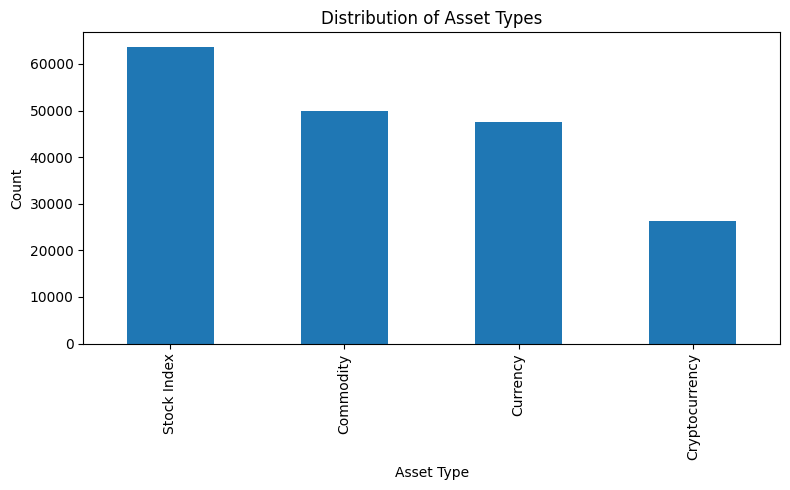

In [8]:
plt.figure(figsize=(8,5))

df["asset_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Asset Types")
plt.xlabel("Asset Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

The dataset contains multiple asset categories distributed globally. This diversity allows for a broad analysis of financial market behavior across different asset classes.

## Market Coverage Analysis

Understanding the temporal coverage of the dataset is important before performing trend analysis. This section examines the time span covered by the dataset and its representation across different market periods.

In [9]:
# convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

start_date = df["date"].min()
end_date = df["date"].max()

print("Start Date :", start_date.date())
print("End Date   :", end_date.date())
print("Total Years:", round((end_date - start_date).days / 365, 2))

Start Date : 2000-01-03
End Date   : 2026-05-29
Total Years: 26.42


In [10]:
df["year"] = df["date"].dt.year

records_per_year = (
    df["year"]
    .value_counts()
    .sort_index()
)

records_per_year.head()

year
2000    3124
2001    4261
2002    4491
2003    4575
2004    5824
Name: count, dtype: int64

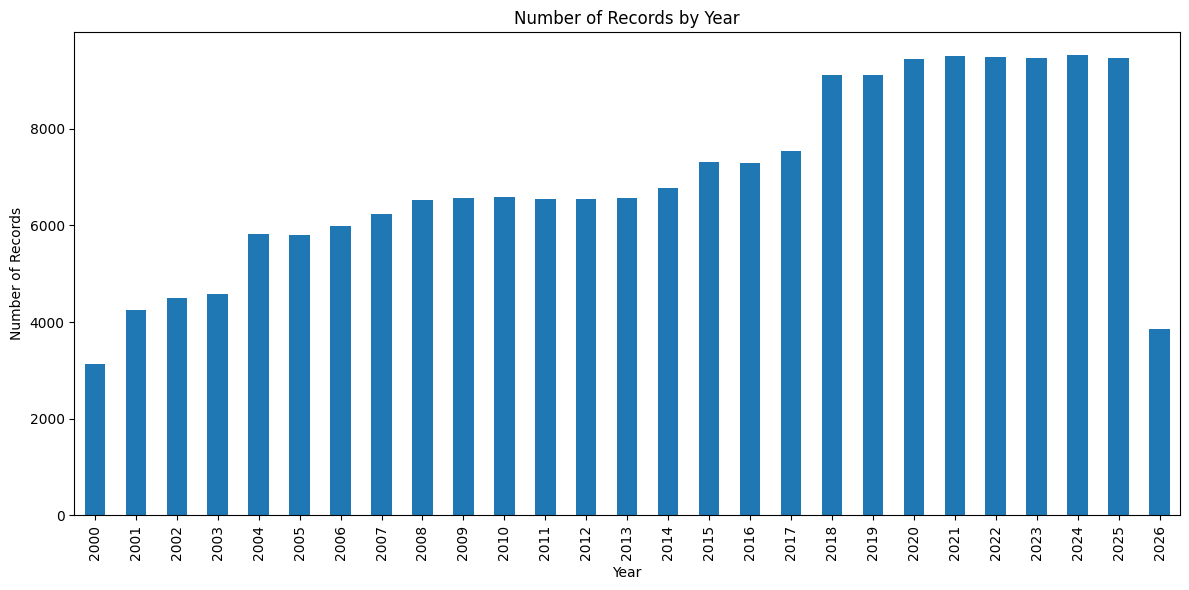

In [11]:
plt.figure(figsize=(12,6))

records_per_year.plot(kind="bar")

plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The dataset covers the period from 2000 to 2026 and shows a generally increasing number of records over time. Record counts rise steadily from the early 2000s, indicating an expansion in market coverage and asset representation. The highest number of records is observed between 2020 and 2025, reflecting the broadest market coverage during the study period. The lower count for 2026 is expected, as the dataset contains data only up to May 2026 rather than the complete year.

## Trading Volume Analysis

Trading volume is an important indicator of market activity and liquidity. Analyzing volume patterns can help identify periods of increased investor participation and market interest.

In [12]:
df["volume"].describe()

count    1.876110e+05
mean     1.247674e+09
std      5.489795e+09
min      0.000000e+00
25%      0.000000e+00
50%      7.182200e+04
75%      2.232844e+08
max      3.509679e+11
Name: volume, dtype: float64

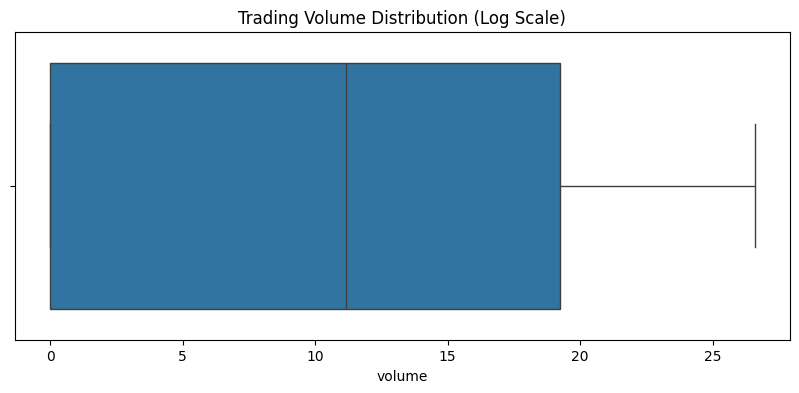

In [13]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=np.log1p(df["volume"])
)

plt.title("Trading Volume Distribution (Log Scale)")

plt.show()

#### Observation

The boxplot reveals a wide spread in trading volume across observations and highlights the presence of numerous high-volume outliers. These extreme values are expected in financial market data and likely correspond to highly liquid assets or periods of elevated market activity. The use of a logarithmic scale improves visibility of the overall distribution while reducing the influence of extreme values.

In [14]:
top_volume = (
    df.groupby("asset_name")["volume"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_volume

asset_name
Bitcoin     95140825495054
Ethereum    47484208040675
S&P500      22921812500000
NASDAQ      19110465960000
HSI         10549980300000
Ripple       8953618671605
FTSE100      7064569250000
Solana       5402507050706
Litecoin     5192510970160
Dogecoin     3982404922403
Name: volume, dtype: int64

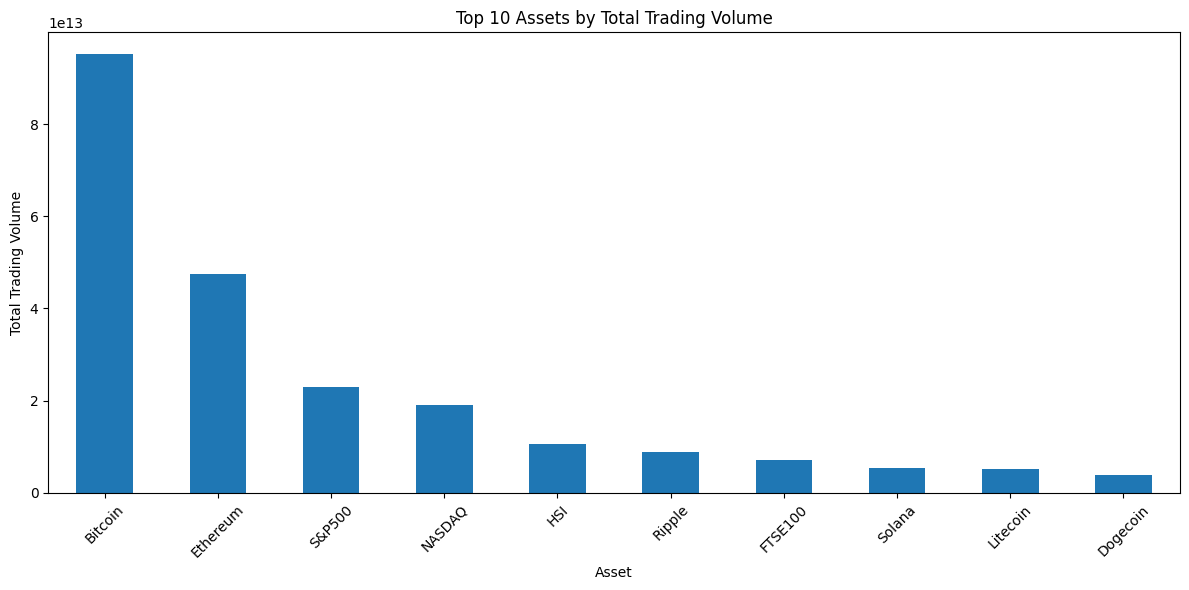

In [15]:
plt.figure(figsize=(12,6))

top_volume.plot(kind="bar")

plt.title("Top 10 Assets by Total Trading Volume")
plt.xlabel("Asset")
plt.ylabel("Total Trading Volume")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

Bitcoin dominates the dataset in terms of total trading volume, with a volume nearly twice that of Ethereum, the second-ranked asset. Among traditional financial assets, the S&P 500 and NASDAQ indices account for the highest trading activity, reflecting their importance in global financial markets. The presence of multiple cryptocurrencies, including Bitcoin, Ethereum, Ripple, Solana, Litecoin, and Dogecoin, among the top-ranked assets highlights the substantial growth and market participation within the cryptocurrency sector during the study period.

In [16]:
avg_volume_type = (
    df.groupby("asset_type")["volume"]
      .mean()
      .sort_values(ascending=False)
)

avg_volume_type

asset_type
Cryptocurrency    6.554379e+09
Stock Index       9.588466e+08
Commodity         7.247133e+04
Currency          0.000000e+00
Name: volume, dtype: float64

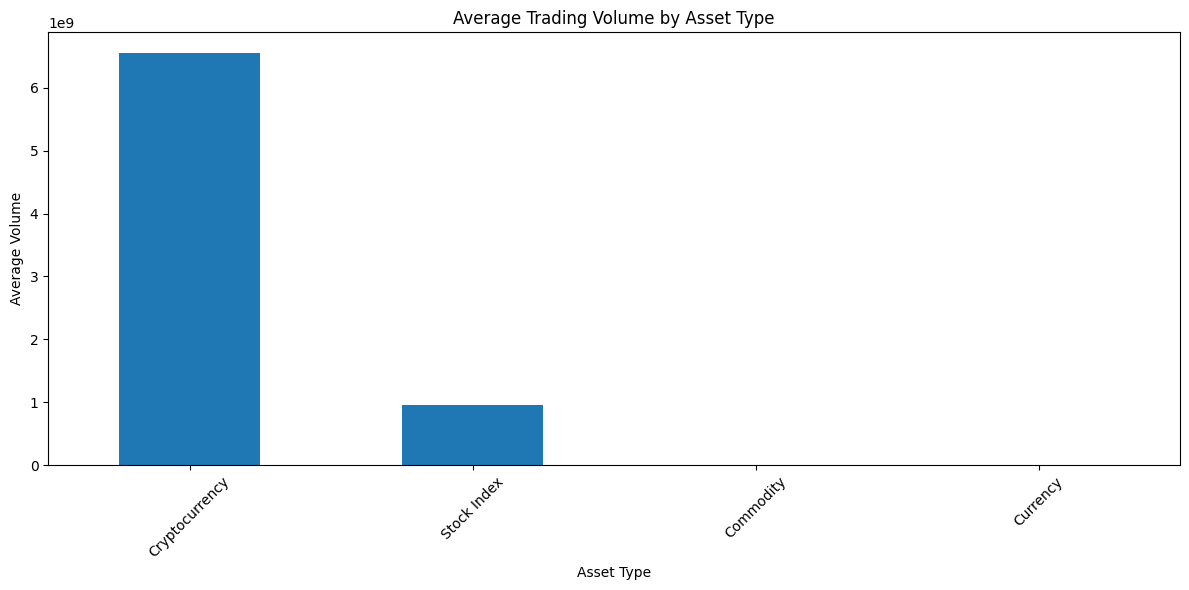

In [17]:
plt.figure(figsize=(12,6))

avg_volume_type.plot(kind="bar")

plt.title("Average Trading Volume by Asset Type")
plt.xlabel("Asset Type")
plt.ylabel("Average Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Observation

Cryptocurrencies exhibit the highest average trading volume among all asset types in the dataset, significantly exceeding stock indices, commodities, and currencies. Stock indices rank second but remain substantially below cryptocurrencies in terms of average market activity. The relatively low average volumes observed for commodities and currency pairs suggest lower reported trading activity compared to the highly liquid cryptocurrency market.

In [18]:
asset_counts = df["asset_type"].value_counts()

avg_volume = (
    df.groupby("asset_type")["volume"]
      .mean()
)

comparison = pd.DataFrame({
    "count": asset_counts,
    "avg_volume": avg_volume
}).loc[asset_counts.index]

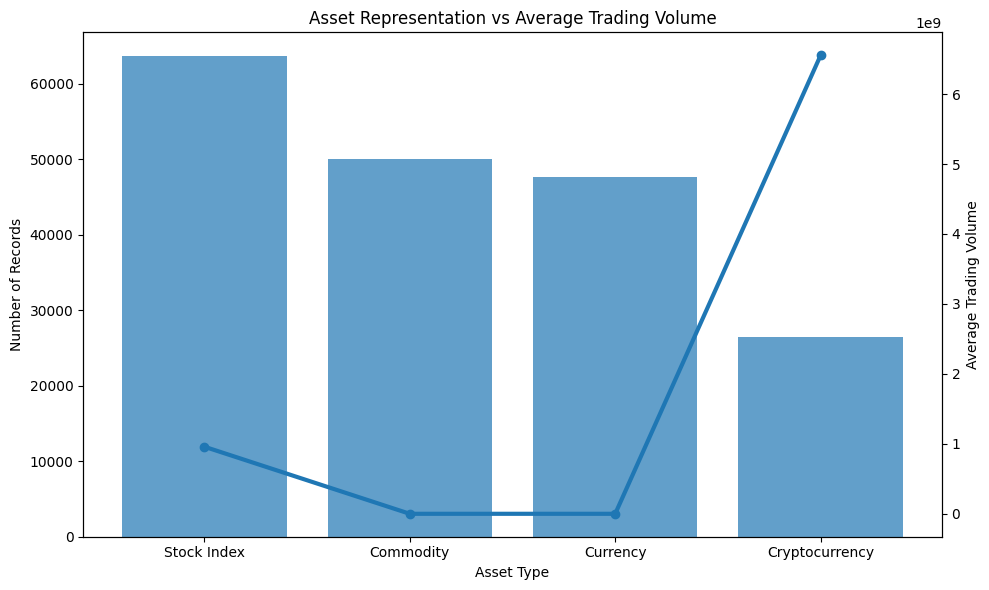

In [19]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for counts
ax1.bar(
    comparison.index,
    comparison["count"],
    alpha=0.7,
    label="Record Count"
)

ax1.set_ylabel("Number of Records")
ax1.set_xlabel("Asset Type")

# Second axis for volume
ax2 = ax1.twinx()

ax2.plot(
    comparison.index,
    comparison["avg_volume"],
    marker="o",
    linewidth=3,
    label="Average Trading Volume"
)

ax2.set_ylabel("Average Trading Volume")

plt.title(
    "Asset Representation vs Average Trading Volume"
)

plt.tight_layout()
plt.show()

#### Observation

Although cryptocurrencies represent the smallest asset category in terms of the number of records, they exhibit by far the highest average trading volume. In contrast, stock indices, commodities, and currencies account for a larger share of observations but generate substantially lower trading activity on average. This indicates that cryptocurrency markets experience significantly higher trading intensity relative to their representation in the dataset.

### Overall Observation

The trading volume analysis reveals significant differences in market activity across asset types and individual assets. Trading volume is highly concentrated among a small number of assets, with Bitcoin and Ethereum accounting for a substantial share of total market activity. While stock indices constitute the largest portion of the dataset by record count, cryptocurrencies demonstrate considerably higher average trading volumes, indicating greater trading intensity and market participation. Furthermore, the distribution of trading volume is highly skewed, with a small number of observations exhibiting exceptionally large volumes compared to the majority of records. Overall, the results highlight the dominant role of major cryptocurrencies in driving trading activity within the dataset despite their relatively smaller representation.

#### Key Findings

- Trading volume is unevenly distributed across assets and asset types.
- Bitcoin records the highest total trading volume, followed by Ethereum.
- Cryptocurrencies exhibit the highest average trading volume among all asset categories.
- Stock indices have the largest number of records but lower average trading activity than cryptocurrencies.
- Trading volume distribution is highly right-skewed, indicating the presence of a small number of extremely high-volume observations.
- A relatively small group of assets accounts for a substantial portion of total market activity.

## Time Series Analysis

Financial market data is inherently time-dependent, making temporal analysis essential for understanding long-term trends and short-term fluctuations. This section examines the evolution of average closing prices across different time horizons, including daily, monthly, quarterly, and yearly aggregations.

By analyzing multiple levels of time aggregation, it becomes possible to reduce short-term market noise and reveal broader market trends, cyclical patterns, and periods of significant growth or decline. These visualizations provide a comprehensive view of how global financial markets have evolved throughout the study period.

### Average Closing Price Across Different Time Horizons

The following visualizations present the average closing price aggregated at daily, monthly, quarterly, and yearly frequencies. Comparing these time scales helps illustrate how market volatility diminishes as data is aggregated over longer periods, making underlying trends easier to interpret.

In [20]:
# Create aggregated datasets

daily = (
    df.groupby("date")["close"]
      .mean()
)

monthly = (
    df.set_index("date")
      .resample("ME")["close"]
      .mean()
)

quarterly = (
    df.set_index("date")
      .resample("QE")["close"]
      .mean()
)

yearly = (
    df.set_index("date")
      .resample("YE")["close"]
      .mean()
)

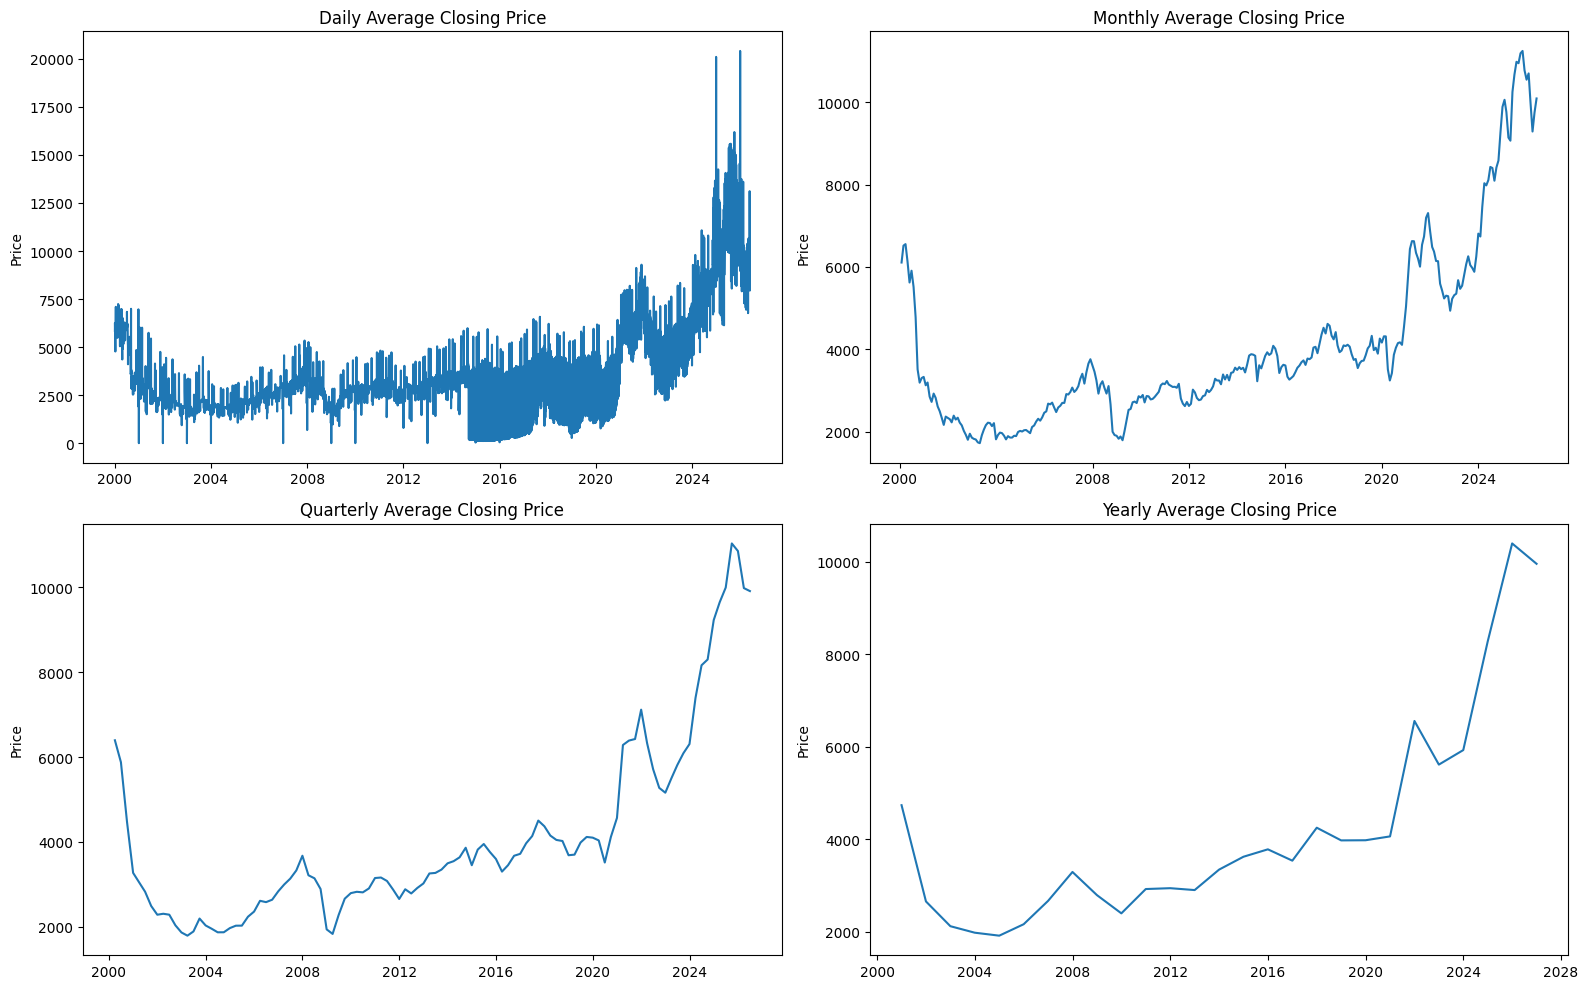

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Daily
axes[0,0].plot(daily.index, daily.values)
axes[0,0].set_title("Daily Average Closing Price")
axes[0,0].set_ylabel("Price")

# Monthly
axes[0,1].plot(monthly.index, monthly.values)
axes[0,1].set_title("Monthly Average Closing Price")
axes[0,1].set_ylabel("Price")

# Quarterly
axes[1,0].plot(quarterly.index, quarterly.values)
axes[1,0].set_title("Quarterly Average Closing Price")
axes[1,0].set_ylabel("Price")

# Yearly
axes[1,1].plot(yearly.index, yearly.values)
axes[1,1].set_title("Yearly Average Closing Price")
axes[1,1].set_ylabel("Price")

plt.tight_layout()
plt.show()

### Observation

The daily series exhibits substantial short-term volatility, reflecting frequent market fluctuations and asset-specific movements. As the data is aggregated to monthly, quarterly, and yearly frequencies, these short-term variations become progressively smoother, revealing the underlying long-term market trajectory more clearly. Across all aggregation levels, the market demonstrates an overall upward trend over the study period, with periods of increased volatility corresponding to major economic and financial events.

### Market Trends Across Key Economic Periods

To better understand how market behavior evolved across different economic cycles, the average yearly closing price is examined within four distinct periods. These periods correspond to major phases in global financial markets, including the post Dot-Com recovery, the Global Financial Crisis, the pre-pandemic expansion period, and the post-pandemic recovery phase.

In [22]:
yearly = (
    df.groupby(pd.Grouper(key="date", freq="YE"))["close"]
      .mean()
      .reset_index()
)

yearly["year"] = yearly["date"].dt.year

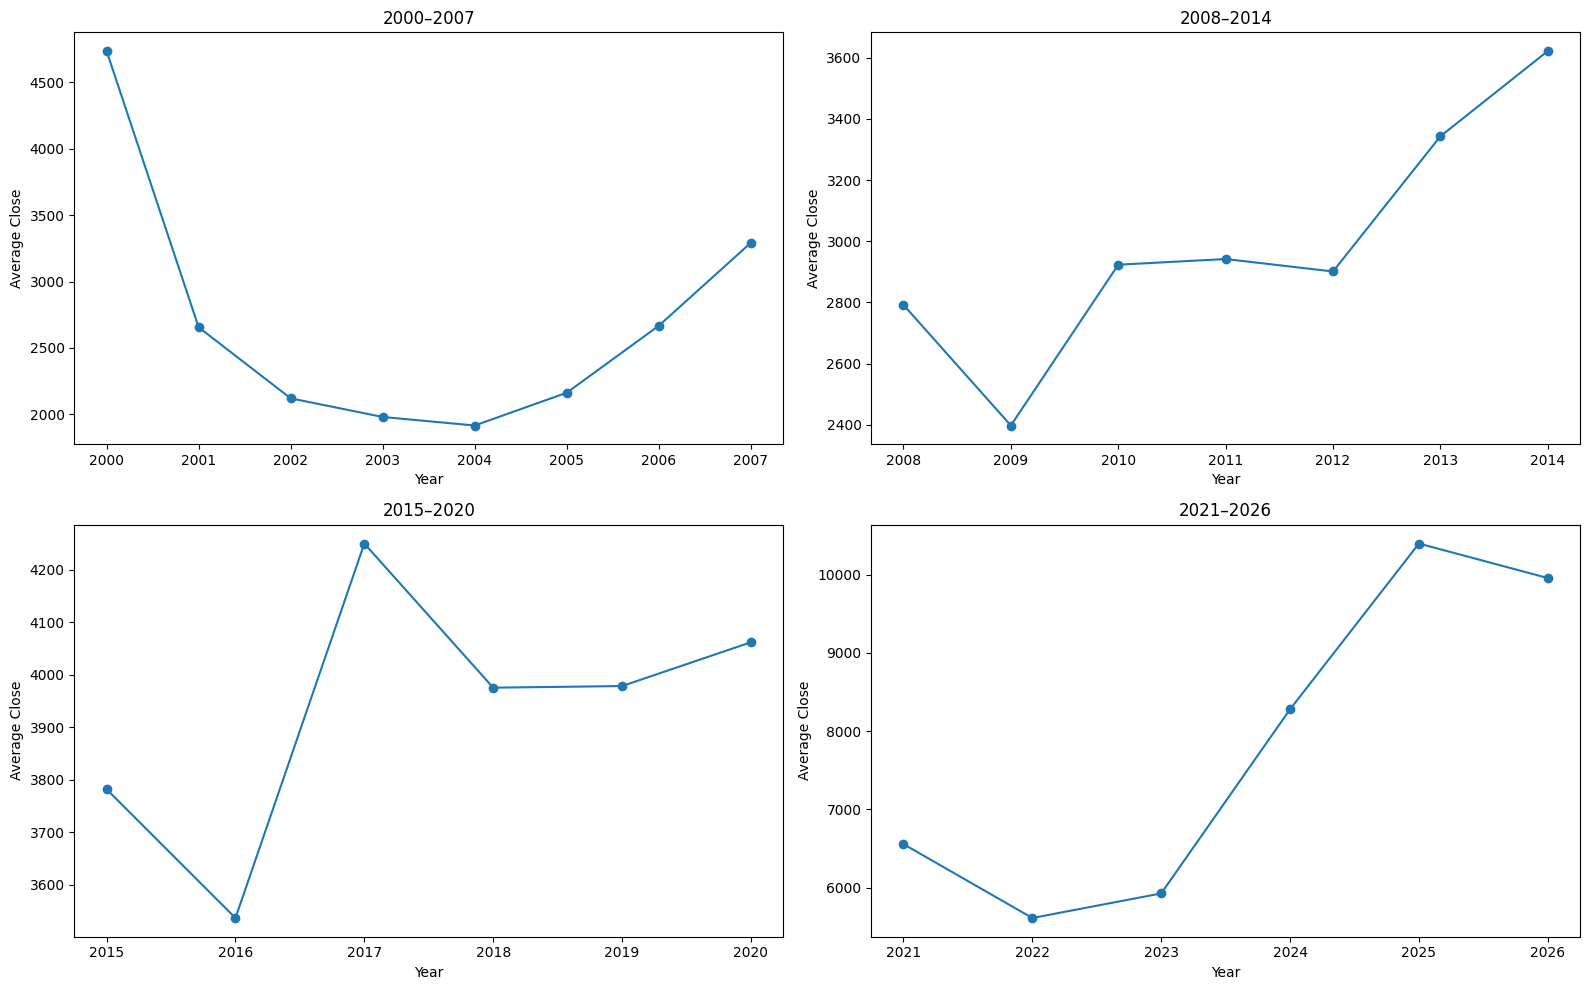

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

periods = [
    (2000, 2007, "2000–2007"),
    (2008, 2014, "2008–2014"),
    (2015, 2020, "2015–2020"),
    (2021, 2026, "2021–2026")
]

for ax, (start, end, title) in zip(axes.flatten(), periods):

    temp = yearly[
        (yearly["year"] >= start) &
        (yearly["year"] <= end)
    ]

    ax.plot(
        temp["year"],
        temp["close"],
        marker="o"
    )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Average Close")

plt.tight_layout()
plt.show()

### Observation

The segmented yearly trend analysis highlights distinct phases of market behavior across the study period, each influenced by major economic and financial events.

During the **2000–2007 period**, the market experienced a sharp decline from approximately 4,700 in 2000 to below 2,000 by 2004. This prolonged downturn aligns with the aftermath of the Dot-Com Crash, which significantly impacted global equity markets. Following this correction phase, the market gradually recovered between 2005 and 2007, with average closing prices rising steadily and reaching approximately 3,300 by the end of the period.

The **2008–2014 period** begins with another notable decline in 2009, reflecting the impact of the Global Financial Crisis. Average closing prices fell from around 2,800 in 2008 to approximately 2,400 in 2009. However, the market demonstrated resilience and recovered strongly in subsequent years. Between 2010 and 2012, prices stabilized near the 2,900 level before accelerating upward, reaching approximately 3,600 by 2014 and marking the completion of a sustained post-crisis recovery.

During the **2015–2020 period**, market performance was comparatively stable. After a modest decline in 2016, average closing prices increased sharply in 2017, reaching the highest level of the period. A correction followed in 2018, after which prices remained relatively stable through 2019. By 2020, the market had resumed moderate growth despite the uncertainty and volatility associated with the onset of the COVID-19 pandemic.

The **2021–2026 period** exhibits the strongest growth of the entire dataset. Following a decline in 2022, the market entered a phase of rapid expansion, with average closing prices increasing substantially from approximately 5,900 in 2023 to over 10,000 by 2025. This sharp upward movement reflects the strong post-pandemic recovery, increased investor participation, and growing activity across several asset classes, particularly cryptocurrencies. Although a slight decline is observed in 2026, the overall trend remains strongly positive and significantly above previous historical levels.

Overall, the analysis demonstrates that while financial markets experience periodic downturns driven by major economic events, they consistently recover and continue to exhibit long-term growth. The post-2020 recovery phase stands out as the most significant expansionary period within the entire study horizon.

## Rolling Trend Analysis

While time-series plots provide a detailed view of market movements, short-term fluctuations can sometimes obscure broader trends. Rolling averages help smooth temporary volatility and reveal the underlying direction of the market over time.

This section uses moving averages to identify long-term trends and better understand the overall behavior of financial markets throughout the study period.

In [24]:
monthly_df = (
    df.groupby(pd.Grouper(key="date", freq="ME"))["close"]
      .mean()
      .reset_index()
)

monthly_df.head()

,date,close
0,2000-01-31,6106.112557
1,2000-02-29,6516.366703
2,2000-03-31,6552.925150
3,2000-04-30,6135.116190
4,2000-05-31,5621.171464


In [25]:
monthly_df["MA_12"] = (
    monthly_df["close"]
      .rolling(window=12)
      .mean()
)

monthly_df["MA_24"] = (
    monthly_df["close"]
      .rolling(window=24)
      .mean()
)

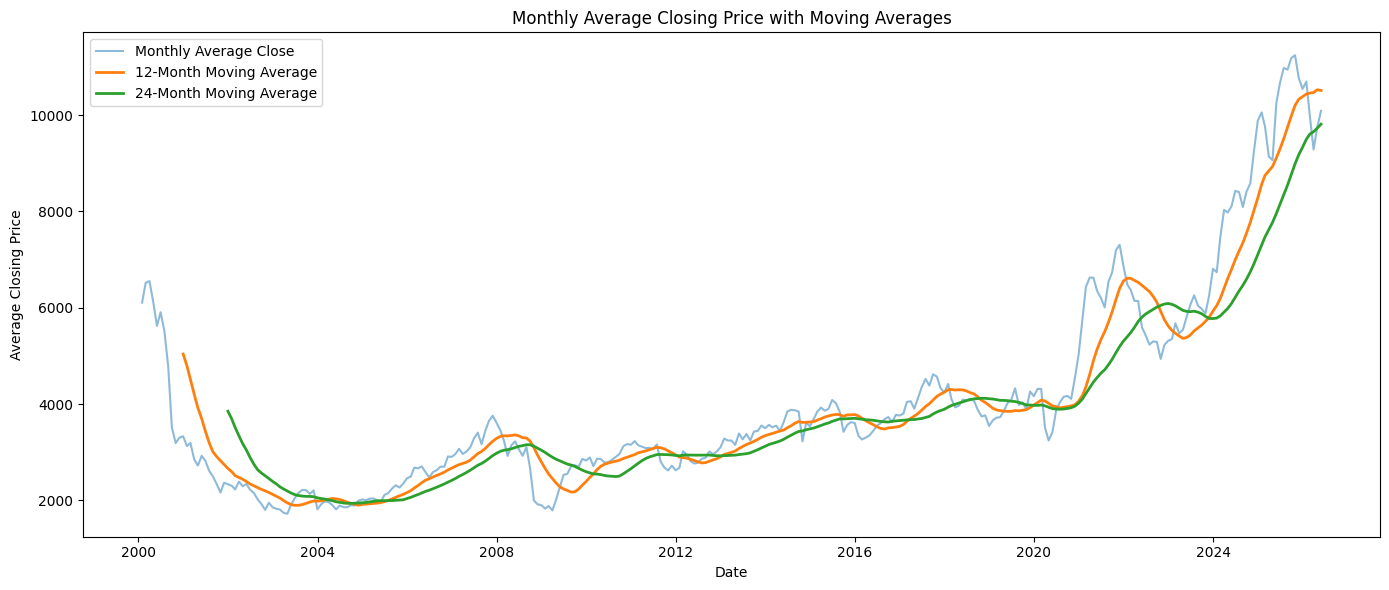

In [26]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df["date"],
    monthly_df["close"],
    label="Monthly Average Close",
    alpha=0.5
)

plt.plot(
    monthly_df["date"],
    monthly_df["MA_12"],
    label="12-Month Moving Average",
    linewidth=2
)

plt.plot(
    monthly_df["date"],
    monthly_df["MA_24"],
    label="24-Month Moving Average",
    linewidth=2
)

plt.title("Monthly Average Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")

plt.legend()

plt.tight_layout()
plt.show()

### Observation

The moving average analysis provides a clearer view of the long-term market trend by reducing the impact of short-term price fluctuations. The 12-month moving average captures medium-term market movements and responds more quickly to changes in market conditions, while the 24-month moving average offers a smoother representation of the underlying long-term trend by filtering out a greater portion of short-term volatility.

The chart reveals a significant decline in average closing prices during the early 2000s, followed by a period of gradual recovery and relatively stable growth through the following decade. Temporary downturns are visible around major market events, including the 2008 Global Financial Crisis and the market disruptions associated with the COVID-19 pandemic. However, both moving averages indicate that these declines were followed by recoveries, highlighting the resilience of financial markets over time.

From 2021 onward, the moving averages exhibit a notably steeper upward slope, reflecting a period of accelerated market growth. The widening gap between the monthly average closing price and the moving averages during recent years indicates increased market volatility, while the moving averages remain comparatively stable and continue to emphasize the broader upward trajectory of the market.

Overall, both the 12-month and 24-month moving averages confirm a strong long-term growth trend across the study period, with the 24-month average particularly effective in highlighting sustained market direction while minimizing the influence of short-term fluctuations.

## Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables in the dataset. Understanding these relationships provides insight into how market indicators move relative to one another and can reveal patterns useful for further analysis.

In [27]:
numeric_cols = ["open", "high", "low", "close", "volume"]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,open,high,low,close,volume
open,1.000000,0.999903,0.999867,0.999836,0.418079
high,0.999903,1.000000,0.999774,0.999907,0.423743
low,0.999867,0.999774,1.000000,0.999891,0.411260
close,0.999836,0.999907,0.999891,1.000000,0.418042
volume,0.418079,0.423743,0.411260,0.418042,1.000000


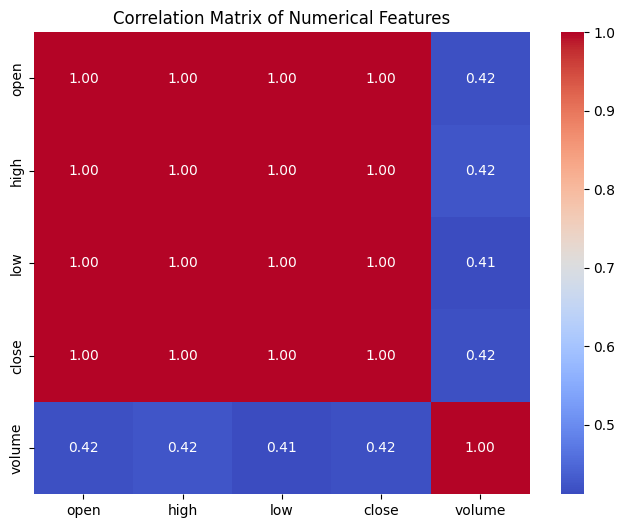

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Observation

The correlation matrix shows a very strong positive relationship among the open, high, low, and close price variables, indicating that these market price indicators tend to move together. Trading volume exhibits a comparatively weaker relationship with price-based variables, suggesting that market activity and price levels do not always increase or decrease simultaneously. Overall, the results confirm the expected interdependence among financial price measures while highlighting the distinct behavior of trading volume.

## Major Market Events Analysis

Financial markets are highly sensitive to major economic, geopolitical, and global events. The time-series and moving-average analyses reveal several periods of heightened volatility and significant shifts in market behavior throughout the study period. These events provide valuable context for understanding long-term market trends and fluctuations observed in the dataset.

### Dot-Com Crash (2000–2002)

The beginning of the dataset coincides with the aftermath of the Dot-Com bubble, a period characterized by excessive speculation in technology-related stocks. Following the collapse of many internet-based companies, global equity markets experienced a substantial decline in valuations. The time-series analysis shows a pronounced downward movement in average closing prices during this period, accompanied by elevated volatility. This market correction marked the end of a rapid growth phase and resulted in a prolonged recovery period during the early 2000s.

### Global Financial Crisis (2008–2009)

Another major decline is visible during the 2008 Global Financial Crisis, one of the most significant economic downturns in modern history. Triggered by the collapse of the U.S. housing market and the failure of major financial institutions, the crisis led to widespread uncertainty across global markets. The dataset reflects this period through a noticeable drop in average closing prices and increased market instability. Although the recovery required several years, financial markets gradually regained momentum as economic conditions improved and policy interventions stabilized the financial system.

### COVID-19 Market Shock (2020)

The onset of the COVID-19 pandemic in 2020 created unprecedented disruptions across global economies. Lockdowns, supply chain interruptions, and uncertainty surrounding economic activity led to sharp fluctuations in financial markets. The time-series analysis indicates increased volatility during this period as investors reacted to rapidly changing economic conditions. Despite the initial shock, markets demonstrated resilience and began recovering as governments and central banks implemented large-scale fiscal and monetary support measures.

### Post-Pandemic Recovery and Market Expansion (2021–2025)

Following the pandemic-related downturn, financial markets entered a strong recovery phase. The moving-average analysis highlights a sustained upward trend beginning in 2021, with market growth accelerating in subsequent years. Increased investor participation, technological innovation, economic reopening, and expanding cryptocurrency adoption contributed to rising market valuations. The steep upward movement observed in both the monthly average closing prices and long-term moving averages suggests that this period experienced some of the strongest growth within the entire dataset. Although volatility remained present, the broader trend indicates continued market expansion and increased financial activity across multiple asset classes.


## Conclusion

The exploratory data analysis provides a comprehensive overview of global financial market behavior between 2000 and 2026. The dataset captures multiple asset classes, regions, and major economic events, offering valuable insights into long-term market dynamics. Analysis of asset composition revealed that stock indices constitute the largest portion of the dataset, while cryptocurrencies, despite their smaller representation, account for the highest levels of trading activity.

The trading volume analysis highlighted a strong concentration of market participation among a limited number of assets, particularly Bitcoin and Ethereum. Time-series and rolling trend analyses demonstrated that financial markets have experienced significant short-term fluctuations while maintaining a clear long-term upward trajectory. Furthermore, correlation analysis confirmed strong relationships among price-based variables, reflecting the interconnected nature of financial market indicators.

Overall, the findings suggest that global financial markets have shown resilience in recovering from major economic disruptions, including the Dot-Com Crash, the Global Financial Crisis, and the COVID-19 pandemic. Despite periods of heightened volatility, the long-term trend indicates sustained market growth and increasing investor participation across various asset classes.

## Key Findings

1. The dataset contains more than two decades of financial market data spanning multiple asset classes and global regions.

2. Stock indices represent the largest asset category by record count, while cryptocurrencies account for the smallest share of observations.

3. Despite lower representation, cryptocurrencies exhibit the highest average trading volume, indicating significantly higher trading intensity.

4. Bitcoin and Ethereum dominate total trading activity and account for a substantial portion of market volume.

5. Trading volume is highly concentrated among a small number of assets and displays a strongly right-skewed distribution.

6. Time-series analysis reveals substantial short-term volatility but a clear long-term upward trend across the study period.

7. Moving average analysis confirms sustained long-term market growth despite temporary downturns associated with major economic events.

8. Strong positive correlations exist among open, high, low, and close prices, while trading volume demonstrates comparatively weaker relationships with price variables.

9. Major events such as the Dot-Com Crash, the Global Financial Crisis, and the COVID-19 pandemic are reflected in periods of increased volatility and market decline.

10. The post-2020 period is characterized by accelerated growth and increased market activity across several asset classes.